In [1]:
import pandas as pd
import os
from utils import buildDataset, analyze_svm_results
import numpy as np
from ovoSVM import OneVsOneSVM
import time

# for validation
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Question 2:: Multi Image Classification
inputClasses = range(10)
print(f"Running for classes : {inputClasses}")
results = {}
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Running for classes : range(0, 10)


In [3]:
print("------Building train set------")
trainingSet = buildDataset(basePath="train", inputClasses = inputClasses)
trainingSet.head()

------Building train set------
Loaded airplane → X: (1667, 3072), y: (1667,)
Loaded automobile → X: (1667, 3072), y: (1667,)
Loaded bird → X: (1667, 3072), y: (1667,)
Loaded cat → X: (1667, 3072), y: (1667,)
Loaded deer → X: (1667, 3072), y: (1667,)
Loaded dog → X: (1667, 3072), y: (1667,)
Loaded frog → X: (1667, 3072), y: (1667,)
Loaded horse → X: (1667, 3072), y: (1667,)
Loaded ship → X: (1667, 3072), y: (1667,)
Loaded truck → X: (1667, 3072), y: (1667,)
Suffling to mix both classes

Final Dataset Shape train: (16670, 3073)


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,0.960784,0.980392,0.992157,0.960784,0.984314,0.984314,0.960784,0.984314,0.984314,0.960784,...,0.431373,0.427451,0.419608,0.431373,0.423529,0.435294,0.431373,0.423529,0.435294,8
1,0.427451,0.635294,0.756863,0.419608,0.619608,0.725490,0.403922,0.580392,0.662745,0.415686,...,0.160784,0.352941,0.470588,0.176471,0.372549,0.470588,0.188235,0.384314,0.474510,8
2,0.678431,0.635294,0.611765,0.725490,0.682353,0.658824,0.721569,0.670588,0.647059,0.596078,...,0.862745,0.792157,0.792157,0.764706,0.694118,0.694118,0.756863,0.686275,0.686275,6
3,0.254902,0.180392,0.188235,0.337255,0.266667,0.258824,0.341176,0.274510,0.243137,0.392157,...,0.176471,0.164706,0.145098,0.196078,0.156863,0.149020,0.168627,0.125490,0.117647,6
4,0.968627,1.000000,1.000000,0.968627,1.000000,1.000000,0.976471,1.000000,1.000000,0.980392,...,1.000000,0.988235,0.980392,1.000000,0.988235,0.992157,1.000000,0.984314,0.988235,9


In [4]:
print("------Building test set------")
testingSet = buildDataset(basePath="test", inputClasses = inputClasses)
testingSet.head()

------Building test set------
Loaded airplane → X: (333, 3072), y: (333,)
Loaded automobile → X: (333, 3072), y: (333,)
Loaded bird → X: (333, 3072), y: (333,)
Loaded cat → X: (333, 3072), y: (333,)
Loaded deer → X: (333, 3072), y: (333,)
Loaded dog → X: (333, 3072), y: (333,)
Loaded frog → X: (333, 3072), y: (333,)
Loaded horse → X: (333, 3072), y: (333,)
Loaded ship → X: (333, 3072), y: (333,)
Loaded truck → X: (333, 3072), y: (333,)
Suffling to mix both classes

Final Dataset Shape test: (3330, 3073)


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,0.431373,0.215686,0.188235,0.400000,0.207843,0.192157,0.313726,0.145098,0.172549,0.227451,...,0.556863,0.533333,0.572549,0.560784,0.521569,0.552941,0.556863,0.521569,0.541176,1
1,0.011765,0.000000,0.007843,0.015686,0.000000,0.011765,0.023529,0.000000,0.007843,0.023529,...,0.023529,0.007843,0.003922,0.019608,0.003922,0.000000,0.019608,0.003922,0.000000,5
2,0.317647,0.301961,0.290196,0.286275,0.270588,0.258824,0.258824,0.254902,0.239216,0.254902,...,0.098039,0.137255,0.105882,0.078431,0.105882,0.074510,0.094118,0.121569,0.090196,2
3,0.549020,0.552941,0.388235,0.858824,0.866667,0.709804,0.835294,0.854902,0.698039,0.847059,...,0.254902,0.356863,0.172549,0.176471,0.223529,0.066667,0.243137,0.274510,0.129412,5
4,0.968627,0.992157,1.000000,0.949020,0.972549,1.000000,0.870588,0.890196,0.964706,0.713726,...,0.360784,0.313726,0.211765,0.372549,0.329412,0.211765,0.439216,0.400000,0.262745,9


In [5]:
def plotConfusionMatrix(y_test, y_preds, class_names):
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_preds, labels=range(len(class_names)))
    plt.figure(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Custom CVXOPT OVO SVM")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def misClassifiedExamples(y_test, y_pred, class_names):
    # Find misclassified indices (for CVXOPT model)
    mis_idx = np.where(y_pred != y_test)[0]
    
    print(f"Total misclassified samples: {len(mis_idx)}")
    print("Showing 10 examples...\n")
    
    num_show = min(10, len(mis_idx))
    plt.figure(figsize=(15, 5))
    
    for i, idx in enumerate(mis_idx[:num_show]):
        img = X_test.iloc[idx].to_numpy().reshape(32, 32, 3)
        plt.subplot(2, 5, i+1)
        plt.imshow((img - img.min()) / (img.max() - img.min()))  # normalize for display
        true_label = class_names[int(y_test.iloc[idx])]
        pred_label = class_names[int(y_pred[idx])]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis("off")
    
    plt.suptitle("10 Misclassified Examples (Custom CVXOPT OVO SVM)", fontsize=14)
    plt.tight_layout()
    plt.show()

       5-Fold Cross-Validation (Custom SVM)   


>>> Evaluating for C = 1e-05
  Fold 1/5: Training model ... Training 45 One-vs-One classifiers...


/home/yscl10/Trishanku Sarma/IITD_MSR_1stSem/COL_7074_Assignments/Assignment2/jupyterlab_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yscl10/Trishanku Sarma/IITD_MSR_1stSem/COL_7074_Assignments/Assignment2/jupyterlab_env/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


done in 284.82s | Val Acc = 10.50%
  Fold 2/5: Training model ... Training 45 One-vs-One classifiers...
done in 284.06s | Val Acc = 10.35%
  Fold 3/5: Training model ... Training 45 One-vs-One classifiers...
done in 285.11s | Val Acc = 10.47%
  Fold 4/5: Training model ... Training 45 One-vs-One classifiers...
done in 283.67s | Val Acc = 10.47%
  Fold 5/5: Training model ... Training 45 One-vs-One classifiers...
done in 283.48s | Val Acc = 10.92%
  >>> Mean 5-Fold CV Accuracy for C=1e-05: 10.54%
  >>> Average Training Time per Fold   : 284.23s
  Training full model for test evaluation ... Training 45 One-vs-One classifiers...
done in 527.44s | Test Acc = 10.00%

>>> Evaluating for C = 0.001
  Fold 1/5: Training model ... Training 45 One-vs-One classifiers...
done in 334.83s | Val Acc = 27.59%
  Fold 2/5: Training model ... Training 45 One-vs-One classifiers...
done in 344.17s | Val Acc = 27.89%
  Fold 3/5: Training model ... Training 45 One-vs-One classifiers...
done in 391.37s | Val A

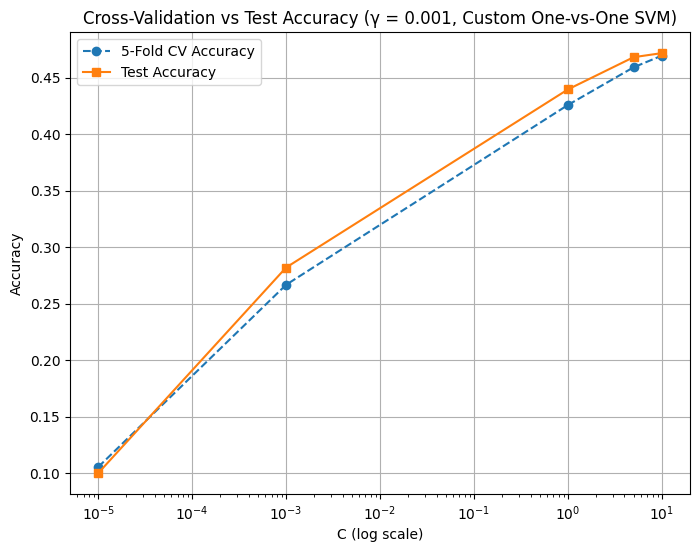


            Best Hyperparameter                
Best C (based on CV): 10
Best 5-Fold CV Accuracy : 46.95%
Corresponding Test Acc   : 47.18%

Training final model using best C = 10 ...
Training 45 One-vs-One classifiers...
Final Model Training Completed in 695.08s
Final Test Accuracy (C=10): 47.18%


In [6]:
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt
import time

# --------------------------------------
# 8. Hyperparameter Tuning (Custom One-vs-One SVM)
# --------------------------------------
C_values = [1e-5, 1e-3, 1, 5, 10]
gamma = 0.001

cv_scores = []
test_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_train, y_train = trainingSet.iloc[:, :-1], trainingSet.iloc[:, -1]
X_test, y_test = testingSet.iloc[:, :-1], testingSet.iloc[:, -1]

print("==============================================")
print("       5-Fold Cross-Validation (Custom SVM)   ")
print("==============================================\n")

for C in C_values:
    print(f"\n>>> Evaluating for C = {C}")
    fold_acc = []
    fold_times = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
        print(f"  Fold {fold}/5: Training model ...", end=" ")
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        start_time = time.time()
        model = OneVsOneSVM(C=C, gamma=gamma)
        model.fit(X_tr, y_tr)
        train_time = time.time() - start_time
        fold_times.append(train_time)

        preds_val = model.predict(X_val)
        acc_val = np.mean(preds_val == y_val)
        fold_acc.append(acc_val)

        print(f"done in {train_time:.2f}s | Val Acc = {acc_val*100:.2f}%")

    mean_cv_acc = np.mean(fold_acc)
    mean_train_time = np.mean(fold_times)
    cv_scores.append(mean_cv_acc)

    print(f"  >>> Mean 5-Fold CV Accuracy for C={C}: {mean_cv_acc*100:.2f}%")
    print(f"  >>> Average Training Time per Fold   : {mean_train_time:.2f}s")

    # Train on full training set and evaluate on test
    print("  Training full model for test evaluation ...", end=" ")
    start_time = time.time()
    model_full = OneVsOneSVM(C=C, gamma=gamma)
    model_full.fit(X_train, y_train)
    preds_test = model_full.predict(X_test)
    test_acc = np.mean(preds_test == y_test)
    test_time = time.time() - start_time
    test_scores.append(test_acc)
    print(f"done in {test_time:.2f}s | Test Acc = {test_acc*100:.2f}%")

print("\n==============================================")
print("         Summary of Cross-Validation           ")
print("==============================================")
print(f"{'C Value':>10} | {'CV Accuracy (%)':>15} | {'Test Accuracy (%)':>18}")
print("-" * 48)
for i, C in enumerate(C_values):
    print(f"{C:>10} | {cv_scores[i]*100:>15.2f} | {test_scores[i]*100:>18.2f}")

# --------------------------------------
# 8(b) Plotting
# --------------------------------------
plt.figure(figsize=(8,6))
plt.plot(C_values, cv_scores, marker='o', linestyle='--', label='5-Fold CV Accuracy')
plt.plot(C_values, test_scores, marker='s', linestyle='-', label='Test Accuracy')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Cross-Validation vs Test Accuracy (γ = 0.001, Custom One-vs-One SVM)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------
# 8(c) Selecting Best C
# --------------------------------------
best_C_index = np.argmax(cv_scores)
best_C = C_values[best_C_index]
best_cv_acc = cv_scores[best_C_index]
best_test_acc = test_scores[best_C_index]

print("\n==============================================")
print("            Best Hyperparameter                ")
print("==============================================")
print(f"Best C (based on CV): {best_C}")
print(f"Best 5-Fold CV Accuracy : {best_cv_acc*100:.2f}%")
print(f"Corresponding Test Acc   : {best_test_acc*100:.2f}%")

# Retrain final model
print(f"\nTraining final model using best C = {best_C} ...")
start_time = time.time()
final_model = OneVsOneSVM(C=best_C, gamma=gamma)
final_model.fit(X_train, y_train)
preds_final = final_model.predict(X_test)
final_test_acc = np.mean(preds_final == y_test)
final_time = time.time() - start_time
print(f"Final Model Training Completed in {final_time:.2f}s")
print(f"Final Test Accuracy (C={best_C}): {final_test_acc*100:.2f}%")


In [7]:
# --------------------------------------
# 8(d) Observations
# --------------------------------------
print("\n==============================================")
print("                Observations                   ")
print("==============================================")
print("• For very small C (e.g., 1e-5), the model is highly regularized and underfits.")
print("• As C increases, the model becomes more flexible and fits better.")
print("• Beyond a certain C, overfitting may appear (test accuracy stops improving).")
print(f"• Best C found via 5-fold CV: {best_C} with {best_cv_acc*100:.2f}% validation accuracy.")
print("• If test accuracy improves over previous fixed-C model, tuning was successful.")


                Observations                   
• For very small C (e.g., 1e-5), the model is highly regularized and underfits.
• As C increases, the model becomes more flexible and fits better.
• Beyond a certain C, overfitting may appear (test accuracy stops improving).
• Best C found via 5-fold CV: 10 with 46.95% validation accuracy.
• If test accuracy improves over previous fixed-C model, tuning was successful.
